# Breast Cancer Classification with a Neural Network

This beginner-friendly notebook builds a simple **Artificial Neural Network (ANN)** to classify breast tumors as:

- **0 → Malignant** (cancerous)
- **1 → Benign** (non-cancerous)

We will use the Breast Cancer Wisconsin dataset from scikit-learn and TensorFlow/Keras to train the model.

### What you will learn
1. Load and explore the dataset
2. Split and standardize features
3. Build, train, and evaluate a neural network
4. Visualize accuracy/loss, confusion matrix, and classification report
5. Make a prediction for a single patient sample

## 1. Importing the Dependencies

In [1]:
# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and preprocessing
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Neural network library
import tensorflow as tf
from tensorflow import keras

# Make results reproducible
tf.random.set_seed(3)
np.random.seed(3)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Data Collection & Processing

We load the built-in Breast Cancer dataset from scikit-learn. It contains **30 numeric features** (such as tumor size and texture) for each sample.

In [2]:
# Load the breast cancer dataset from scikit-learn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

print("Feature names:", list(breast_cancer_dataset.feature_names))
print("Target names:", breast_cancer_dataset.target_names)
print("Number of samples:", breast_cancer_dataset.data.shape[0])
print("Number of features:", breast_cancer_dataset.data.shape[1])

Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]
Target names: ['malignant' 'benign']
Number of samples: 569
Number of features: 30


In [3]:
# Convert the feature array into a pandas DataFrame for easier exploration
data_frame = pd.DataFrame(
    breast_cancer_dataset.data,
    columns=breast_cancer_dataset.feature_names,
)

# Add the target label column (0 = malignant, 1 = benign)
data_frame["label"] = breast_cancer_dataset.target

# Preview the first few rows
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Basic dataset overview
print("Shape (rows, columns):", data_frame.shape)
print("\nMissing values per column:")
print(data_frame.isnull().sum().sum(), "missing values in total")
print("\nData types:")
print(data_frame.dtypes.value_counts())

Shape (rows, columns): (569, 31)

Missing values per column:
0 missing values in total

Data types:
float64    30
int64       1
Name: count, dtype: int64


In [5]:
# Statistical summary of the features
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
# Class distribution
# 0 --> Malignant
# 1 --> Benign
print("Class counts:")
print(data_frame["label"].value_counts())
print("\nClass meaning: 0 = Malignant, 1 = Benign")

Class counts:
label
1    357
0    212
Name: count, dtype: int64

Class meaning: 0 = Malignant, 1 = Benign


In [7]:
# Compare average feature values for each class
data_frame.groupby("label").mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


## 3. Separating Features and Target

- **X** = input features (the 30 measurements)
- **Y** = output label (0 or 1)

In [8]:
X = data_frame.drop(columns="label")
Y = data_frame["label"]

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (569, 30)
Target shape: (569,)


## 4. Train-Test Split

We keep **80%** of the data for training and **20%** for testing.
`stratify=Y` keeps a similar class balance in both sets.

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2,
    stratify=Y,
)

print("Full dataset:", X.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Full dataset: (569, 30)
Training set: (455, 30)
Test set: (114, 30)


## 5. Standardize the Data

Neural networks train better when features are on a similar scale.
We fit the scaler on **training data only**, then apply it to the test data
(this avoids data leakage).

In [10]:
scaler = StandardScaler()

# Fit on training data, then transform both train and test
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("Standardized training data shape:", X_train_std.shape)
print("Standardized test data shape:", X_test_std.shape)

Standardized training data shape: (455, 30)
Standardized test data shape: (114, 30)


## 6. Building the Neural Network

Network architecture:

1. **Input layer** — 30 features
2. **Hidden layer** — 20 neurons with ReLU activation
3. **Output layer** — 2 neurons with Softmax (probabilities for classes 0 and 1)

In [11]:
# Build a simple Sequential neural network
# Input(shape=(30,)) matches our 30 features
model = keras.Sequential(
    [
        keras.Input(shape=(30,)),
        keras.layers.Dense(20, activation="relu", name="hidden_layer"),
        keras.layers.Dense(2, activation="softmax", name="output_layer"),
    ],
    name="breast_cancer_ann",
)

# Compile: choose optimizer, loss, and metrics
# sparse_categorical_crossentropy is used because labels are integers (0 or 1)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Display the model architecture
model.summary()

Model: "breast_cancer_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662 (2.59 KB)

 Trainable params: 662 (2.59 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training the Neural Network

We train for 10 epochs and use 10% of the training data as a validation set
to monitor overfitting.

In [12]:
# Train the model
history = model.fit(
    X_train_std,
    Y_train,
    validation_split=0.1,
    epochs=10,
    verbose=1,
)

Epoch 1/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 7s 620ms/step - accuracy: 0.6250 - loss: 0.6815

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7800 - loss: 0.4472 - val_accuracy: 0.9783 - val_loss: 0.2973


Epoch 2/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8438 - loss: 0.4539

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9375 - loss: 0.1675

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9487 - loss: 0.1278 - val_accuracy: 0.9783 - val_loss: 0.1017


Epoch 10/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9375 - loss: 0.1557

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9535 - loss: 0.1198 - val_accuracy: 0.9783 - val_loss: 0.0972


## 8. Visualizing Accuracy and Loss

These plots show how well the model learned over each epoch.

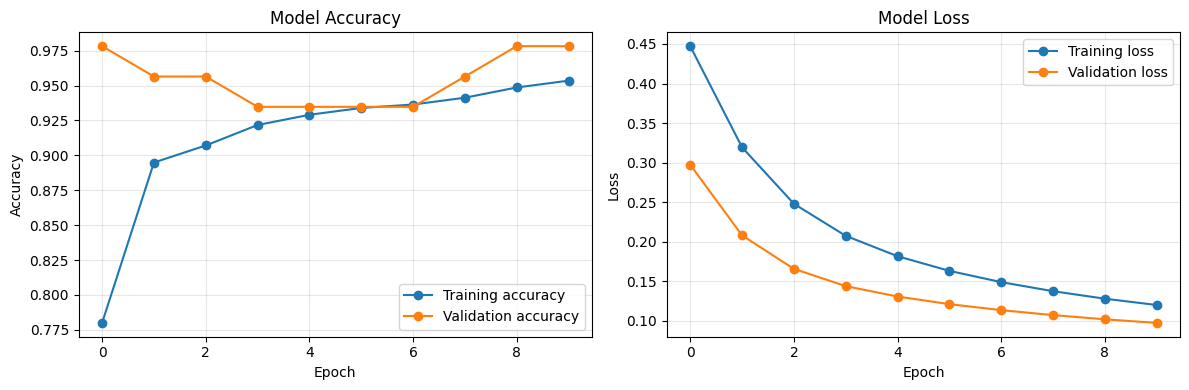

In [13]:
# Plot training and validation accuracy & loss side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy graph
axes[0].plot(history.history["accuracy"], label="Training accuracy", marker="o")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy", marker="o")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Loss graph
axes[1].plot(history.history["loss"], label="Training loss", marker="o")
axes[1].plot(history.history["val_loss"], label="Validation loss", marker="o")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluating on Test Data

Now we check how the trained model performs on unseen test samples.

In [14]:
# Evaluate on the held-out test set
test_loss, test_accuracy = model.evaluate(X_test_std, Y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Test Loss:     0.0988
Test Accuracy: 0.9561 (95.61%)


In [15]:
# Get prediction probabilities for every test sample
# Each row has 2 values: [P(malignant=0), P(benign=1)]
Y_pred_probs = model.predict(X_test_std, verbose=0)

# Convert probabilities to class labels using argmax
# Example: [0.12, 0.88] -> class 1 (Benign)
Y_pred_labels = np.argmax(Y_pred_probs, axis=1)

print("Prediction probabilities shape:", Y_pred_probs.shape)
print("Example probabilities (first sample):", Y_pred_probs[0])
print("Predicted label (first sample):", Y_pred_labels[0])
print("Actual label (first sample):", Y_test.iloc[0])

Prediction probabilities shape: (114, 2)
Example probabilities (first sample): [0.92046106 0.07953895]
Predicted label (first sample): 0
Actual label (first sample): 0


## 10. Confusion Matrix

A confusion matrix shows correct and incorrect predictions for each class.

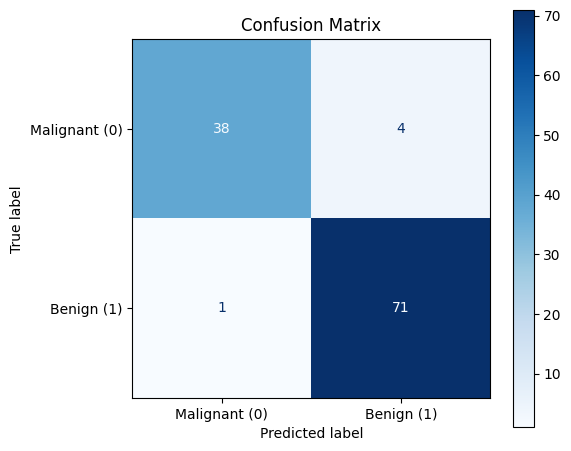

Confusion Matrix values:
[[38  4]
 [ 1 71]]


In [16]:
# Build and display the confusion matrix
cm = confusion_matrix(Y_test, Y_pred_labels)
class_names = ["Malignant (0)", "Benign (1)"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", ax=ax, colorbar=True)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion Matrix values:")
print(cm)

## 11. Classification Report

Precision, recall, and F1-score give a clearer picture than accuracy alone.

In [17]:
# Detailed classification metrics
print("Classification Report:\n")
print(
    classification_report(
        Y_test,
        Y_pred_labels,
        target_names=["Malignant (0)", "Benign (1)"],
        digits=4,
    )
)

Classification Report:

               precision    recall  f1-score   support

Malignant (0)     0.9744    0.9048    0.9383        42
   Benign (1)     0.9467    0.9861    0.9660        72

     accuracy                         0.9561       114
    macro avg     0.9605    0.9454    0.9521       114
 weighted avg     0.9569    0.9561    0.9558       114



## 12. Building a Predictive System

Enter one patient's 30 feature values, standardize them with the **same scaler**,
and let the model predict whether the tumor is malignant or benign.

In [18]:
# Sample patient feature values (30 features in the same order as the dataset)
input_data = (
    11.76, 21.6, 74.72, 427.9, 0.08637, 0.04966, 0.01657, 0.01115,
    0.1495, 0.05888, 0.4062, 1.21, 2.635, 28.47, 0.005857, 0.009758,
    0.01168, 0.007445, 0.02406, 0.001769, 12.98, 25.72, 82.98, 516.5,
    0.1085, 0.08615, 0.05523, 0.03715, 0.2433, 0.06563,
)

# Convert to a 2D array: shape (1, 30) because the model expects a batch
input_data_reshaped = np.asarray(input_data, dtype=float).reshape(1, -1)

# Standardize using the scaler fitted on training data
input_data_std = scaler.transform(input_data_reshaped)

# Get class probabilities
prediction_probs = model.predict(input_data_std, verbose=0)[0]
prediction_label = int(np.argmax(prediction_probs))
confidence = float(prediction_probs[prediction_label])

# Friendly output
label_name = "Malignant" if prediction_label == 0 else "Benign"

print("=" * 50)
print("BREAST CANCER PREDICTION RESULT")
print("=" * 50)
print(f"Predicted class index : {prediction_label}")
print(f"Predicted diagnosis   : {label_name}")
print(f"Confidence            : {confidence * 100:.2f}%")
print("-" * 50)
print(f"P(Malignant = 0)      : {prediction_probs[0] * 100:.2f}%")
print(f"P(Benign = 1)         : {prediction_probs[1] * 100:.2f}%")
print("=" * 50)

if prediction_label == 0:
    print("\nResult: The tumor is predicted to be MALIGNANT.")
else:
    print("\nResult: The tumor is predicted to be BENIGN.")

BREAST CANCER PREDICTION RESULT
Predicted class index : 1
Predicted diagnosis   : Benign
Confidence            : 98.37%
--------------------------------------------------
P(Malignant = 0)      : 1.63%
P(Benign = 1)         : 98.37%

Result: The tumor is predicted to be BENIGN.


C:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Summary

In this notebook we:

1. Loaded and explored the Breast Cancer Wisconsin dataset
2. Split and standardized the data
3. Built a simple ANN with one hidden layer
4. Trained the model and plotted accuracy/loss curves
5. Evaluated with test accuracy, a confusion matrix, and a classification report
6. Made a clear single-sample prediction with confidence scores

**Note:** This is an educational demo, not a medical diagnosis tool.